In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ShopSmart Sales Data — 6 months
data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005,
                 1006, 1007, 1008, 1009, 1010,
                 1011, 1012, 1013, 1014, 1015,
                 1016, 1017, 1018, 1019, 1020],

    "Region": ["North", "south", "East", "West", "North",
                "SOUTH", "East", "West", "North", "South",
                "East", "west", "North", "South", "East",
                "West", "north", "South", "East", "West"],

    "Product": ["Laptop", "Phone", "Tablet", "Laptop", "Phone",
                "Tablet", "Laptop", "Phone", "Tablet", "Laptop",
                "Phone", "Tablet", "Laptop", "Phone", "Tablet",
                "Laptop", "Phone", "Tablet", "Laptop", "Phone"],

    "Units_Sold": [5, 3, 8, 2, 6,
                   4, 7, 12, 3, 1,
                   9, 4, 6, 5, 3,
                   8, 4, 6, 2, 15],

    "Price": [150000, 75000, 50000, 150000, 75000,
              50000, 150000, 75000, 50000, 150000,
              75000, 50000, 150000, 75000, 50000,
              150000, 75000, 50000, 150000, 75000],

    "Month": ["January", "January", "January", "January", "February",
              "February", "February", "February", "March", "March",
              "March", "March", "April", "April", "April",
              "May", "May", "May", "June", "June"],

    "Sales_Rep": ["Chidi", "Amaka", "Emeka", "Ngozi", "Chidi",
                  "Amaka", "Emeka", "Ngozi", "Chidi", "Amaka",
                  "Emeka", "Ngozi", "Chidi", "Amaka", None,
                  "Ngozi", "Chidi", None, "Emeka", "Ngozi"],

    "Revenue": [750000, 225000, 400000, 300000, 450000,
                200000, 1050000, 900000, 150000, 999999999,
                675000, 200000, 900000, 375000, 150000,
                1200000, 300000, 300000, 300000, 1125000]
}

df = pd.DataFrame(data)
print("Original ShopSmart Data:")
print(df)
print("Shape:", df.shape)

Original ShopSmart Data:
    Order_ID Region Product  Units_Sold   Price     Month Sales_Rep    Revenue
0       1001  North  Laptop           5  150000   January     Chidi     750000
1       1002  south   Phone           3   75000   January     Amaka     225000
2       1003   East  Tablet           8   50000   January     Emeka     400000
3       1004   West  Laptop           2  150000   January     Ngozi     300000
4       1005  North   Phone           6   75000  February     Chidi     450000
5       1006  SOUTH  Tablet           4   50000  February     Amaka     200000
6       1007   East  Laptop           7  150000  February     Emeka    1050000
7       1008   West   Phone          12   75000  February     Ngozi     900000
8       1009  North  Tablet           3   50000     March     Chidi     150000
9       1010  South  Laptop           1  150000     March     Amaka  999999999
10      1011   East   Phone           9   75000     March     Emeka     675000
11      1012   west  Tablet

In [2]:
print("=== DATA INVESTIGATION ===")
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

print("\nUnique regions:", df["Region"].unique())
print("Unique products:", df["Product"].unique())
print("Unique months:", df["Month"].unique())

=== DATA INVESTIGATION ===

Missing values:
Order_ID      0
Region        0
Product       0
Units_Sold    0
Price         0
Month         0
Sales_Rep     2
Revenue       0
dtype: int64

Duplicates: 0

Data types:
Order_ID       int64
Region        object
Product       object
Units_Sold     int64
Price          int64
Month         object
Sales_Rep     object
Revenue        int64
dtype: object

Basic statistics:
         Order_ID  Units_Sold          Price       Revenue
count    20.00000   20.000000      20.000000  2.000000e+01
mean   1010.50000    5.650000   93750.000000  5.049750e+07
std       5.91608    3.483419   43585.215987  2.234900e+08
min    1001.00000    1.000000   50000.000000  1.500000e+05
25%    1005.75000    3.000000   50000.000000  2.812500e+05
50%    1010.50000    5.000000   75000.000000  3.875000e+05
75%    1015.25000    7.250000  150000.000000  9.000000e+05
max    1020.00000   15.000000  150000.000000  1.000000e+09

Unique regions: ['North' 'south' 'East' 'West' 'SOUTH'

In [3]:
print("=== DATA CLEANING ===")

# Fix 1 — Standardise region capitalisation
df["Region"] = df["Region"].str.title()
print("Regions fixed:", df["Region"].unique())

# Fix 2 — Fill missing Sales_Rep
df["Sales_Rep"] = df["Sales_Rep"].fillna("Unknown")
print("\nMissing Sales_Rep filled!")

# Fix 3 — Find and fix revenue outlier
print("\nRevenue before fixing:")
print(df[["Order_ID", "Revenue"]].sort_values("Revenue", ascending=False).head(3))

# Order 1010 has Revenue 999999999 — clearly wrong!
# Correct revenue = Units_Sold * Price = 1 * 150000 = 150000
df.loc[df["Order_ID"] == 1010, "Revenue"] = 150000
print("\nRevenue outlier fixed for Order 1010!")

# Fix 4 — Verify Revenue = Units_Sold * Price
df["Expected_Revenue"] = df["Units_Sold"] * df["Price"]
df["Revenue_Match"] = df["Revenue"] == df["Expected_Revenue"]
print("\nRevenue verification:")
print(df[["Order_ID", "Revenue", "Expected_Revenue", "Revenue_Match"]])

print("\nCleaning complete!")
print("Any missing values left?", df.isnull().sum().any())

=== DATA CLEANING ===
Regions fixed: ['North' 'South' 'East' 'West']

Missing Sales_Rep filled!

Revenue before fixing:
    Order_ID    Revenue
9       1010  999999999
15      1016    1200000
19      1020    1125000

Revenue outlier fixed for Order 1010!

Revenue verification:
    Order_ID  Revenue  Expected_Revenue  Revenue_Match
0       1001   750000            750000           True
1       1002   225000            225000           True
2       1003   400000            400000           True
3       1004   300000            300000           True
4       1005   450000            450000           True
5       1006   200000            200000           True
6       1007  1050000           1050000           True
7       1008   900000            900000           True
8       1009   150000            150000           True
9       1010   150000            150000           True
10      1011   675000            675000           True
11      1012   200000            200000           True
12     

In [5]:
print("=== SALES ANALYSIS ===")

# Overall performance
print(f"Total Revenue: ₦{df["Revenue"].sum():,}")
print("Total Units Sold:", df["Units_Sold"].sum())
print("Average Order Value: ₦", round(df["Revenue"].mean(), 2))
print("Best Order: ₦", df["Revenue"].max())
print("Worst Order: ₦", df["Revenue"].min())

# Revenue by Region
print("\n--- Revenue by Region ---")
region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
print(region_revenue)

# Revenue by Product
print("\n--- Revenue by Product ---")
product_revenue = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
print(product_revenue)

# Revenue by Month
print("\n--- Revenue by Month ---")
month_order = ["January", "February", "March", "April", "May", "June"]
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue = monthly_revenue.reindex(month_order)
print(monthly_revenue)

# Best Sales Rep
print("\n--- Revenue by Sales Rep ---")
rep_revenue = df.groupby("Sales_Rep")["Revenue"].sum().sort_values(ascending=False)
print(rep_revenue)

# Units sold by product
print("\n--- Units Sold by Product ---")
product_units = df.groupby("Product")["Units_Sold"].sum().sort_values(ascending=False)
print(product_units)

=== SALES ANALYSIS ===
Total Revenue: ₦10,100,000
Total Units Sold: 113
Average Order Value: ₦ 505000.0
Best Order: ₦ 1200000
Worst Order: ₦ 150000

--- Revenue by Region ---
Region
West     3725000
East     2575000
North    2550000
South    1250000
Name: Revenue, dtype: int64

--- Revenue by Product ---
Product
Laptop    4650000
Phone     4050000
Tablet    1400000
Name: Revenue, dtype: int64

--- Revenue by Month ---
Month
January     1675000
February    2600000
March       1175000
April       1425000
May         1800000
June        1425000
Name: Revenue, dtype: int64

--- Revenue by Sales Rep ---
Sales_Rep
Ngozi      3725000
Chidi      2550000
Emeka      2425000
Amaka       950000
Unknown     450000
Name: Revenue, dtype: int64

--- Units Sold by Product ---
Product
Phone     54
Laptop    31
Tablet    28
Name: Units_Sold, dtype: int64


In [6]:
print("=== STATISTICAL ANALYSIS ===")

# Outlier detection on Revenue
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Revenue Q1:", Q1)
print("Revenue Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:", lower)
print("Upper boundary:", upper)

outliers = df[(df["Revenue"] < lower) | (df["Revenue"] > upper)]
print("\nRevenue outliers after cleaning:")
print(outliers[["Order_ID", "Region", "Product", "Revenue"]])

# Correlation analysis
print("\n--- Correlation Analysis ---")
corr = df[["Units_Sold", "Revenue", "Price"]].corr().round(2)
print(corr)

# Probability analysis
total_orders = len(df)
high_revenue = len(df[df["Revenue"] >= 500000])
print("\nProbability of high revenue order (>=500k):", round(high_revenue/total_orders, 2))

=== STATISTICAL ANALYSIS ===
Revenue Q1: 218750.0
Revenue Q3: 787500.0
IQR: 568750.0
Lower boundary: -634375.0
Upper boundary: 1640625.0

Revenue outliers after cleaning:
Empty DataFrame
Columns: [Order_ID, Region, Product, Revenue]
Index: []

--- Correlation Analysis ---
            Units_Sold  Revenue  Price
Units_Sold        1.00     0.77  -0.17
Revenue           0.77     1.00   0.42
Price            -0.17     0.42   1.00

Probability of high revenue order (>=500k): 0.35


=== CREATING VISUALISATIONS ===


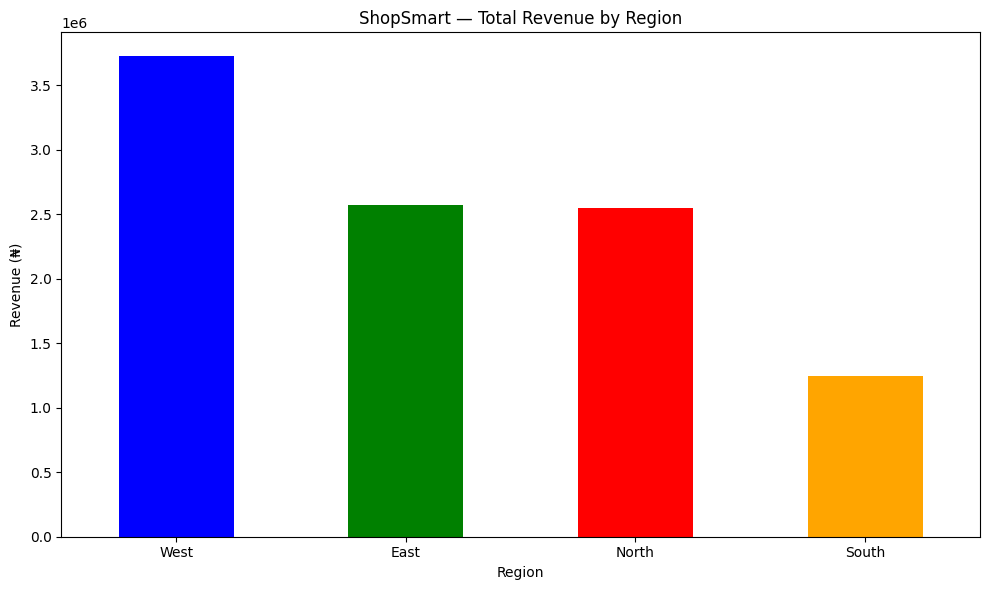

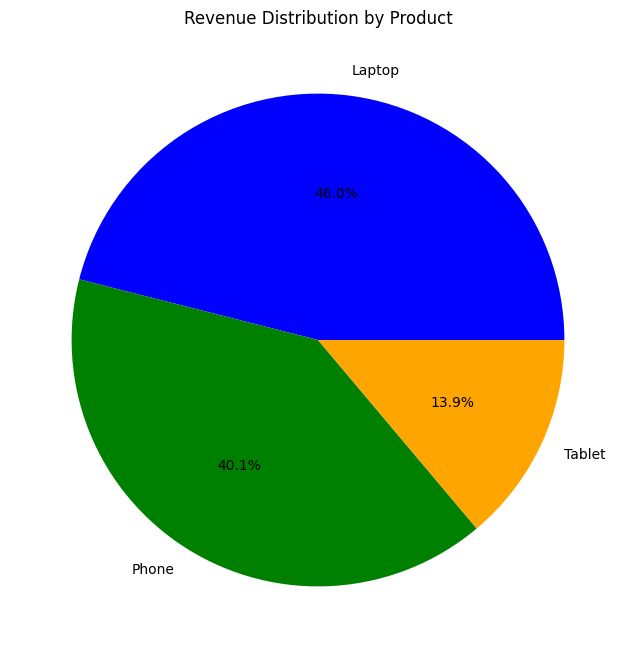

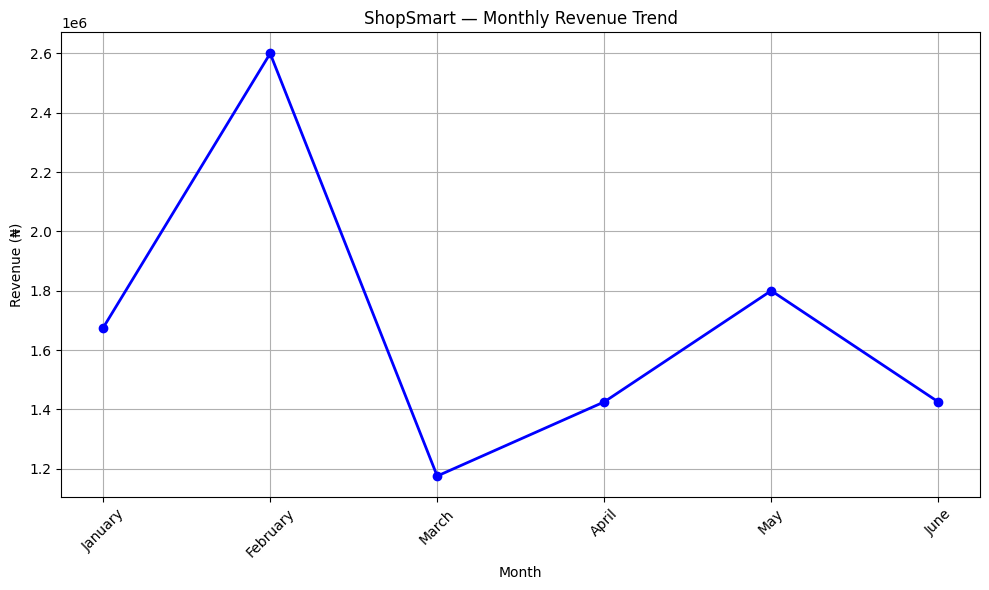

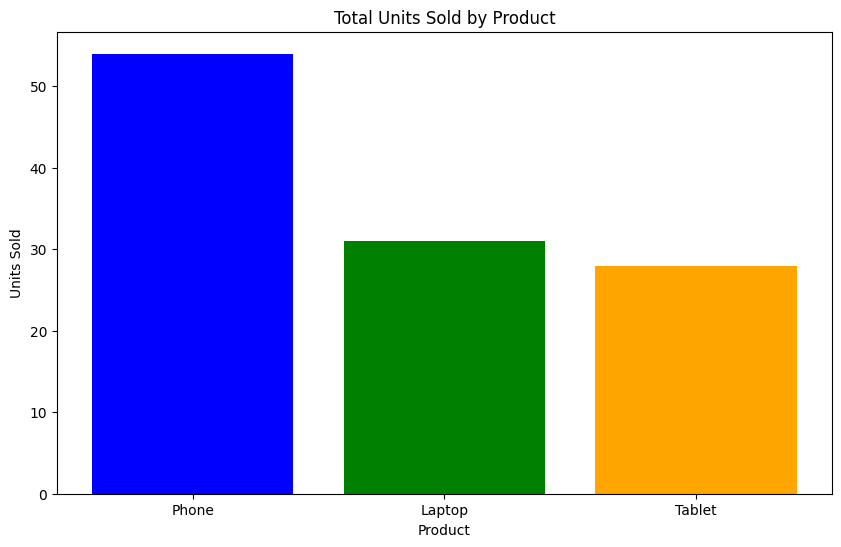

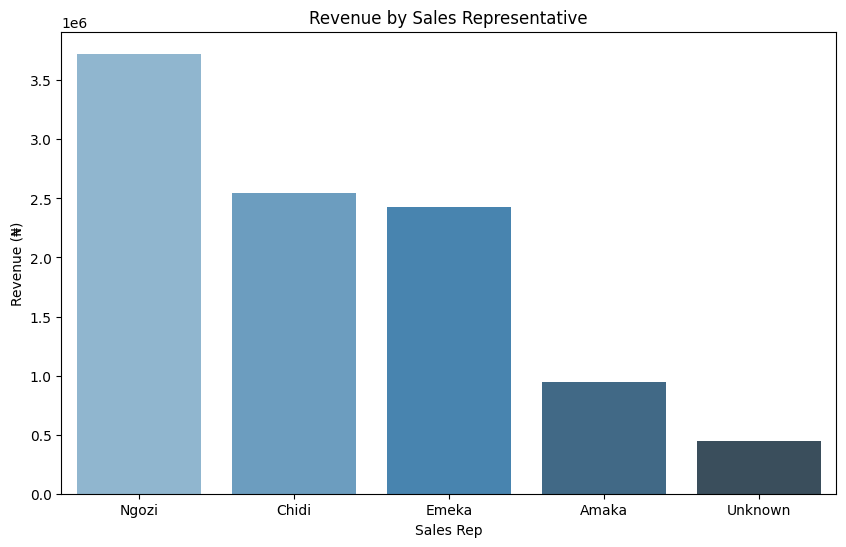

In [7]:
print("=== CREATING VISUALISATIONS ===")

# Chart 1 — Revenue by Region
plt.figure(figsize=(10, 6))
colors = ["blue", "green", "red", "orange"]
region_revenue.plot(kind="bar", color=colors)
plt.title("ShopSmart — Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₦)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chart 2 — Revenue by Product (Pie)
plt.figure(figsize=(8, 8))
plt.pie(product_revenue.values,
        labels=product_revenue.index,
        autopct="%1.1f%%",
        colors=["blue", "green", "orange"])
plt.title("Revenue Distribution by Product")
plt.show()

# Chart 3 — Monthly Revenue Trend
plt.figure(figsize=(10, 6))
plt.plot(month_order, monthly_revenue.values,
         color="blue", marker="o", linewidth=2)
plt.title("ShopSmart — Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₦)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 4 — Units Sold by Product
plt.figure(figsize=(10, 6))
plt.bar(product_units.index, product_units.values,
        color=["blue", "green", "orange"])
plt.title("Total Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()

# Chart 5 — Revenue by Sales Rep
plt.figure(figsize=(10, 6))
sns.barplot(x=rep_revenue.index,
            y=rep_revenue.values,
            palette="Blues_d",
            hue=rep_revenue.index,
            legend=False)
plt.title("Revenue by Sales Representative")
plt.xlabel("Sales Rep")
plt.ylabel("Revenue (₦)")
plt.show()

In [9]:
print("=" * 50)
print("   SHOPSMART SALES REPORT — H1 2026")
print("=" * 50)

print("\n📊 OVERALL PERFORMANCE")
print(f"Total Revenue:     ₦{df['Revenue'].sum():,}")
print(f"Total Orders:       {len(df)}")
print(f"Total Units Sold:   {df['Units_Sold'].sum()}")

print("\n🏆 TOP PERFORMERS")
print(f"Best Region:    {region_revenue.index[0]} (₦{region_revenue.values[0]:,})")
print(f"Best Product:   {product_revenue.index[0]} (₦{product_revenue.values[0]:,})")
print(f"Best Month:     {monthly_revenue.idxmax()} (₦{monthly_revenue.max():,})")
print(f"Best Sales Rep: {rep_revenue.index[0]} (₦{rep_revenue.values[0]:,})")

print("\n⚠️ ISSUES FOUND & FIXED")
print("1. Region names had inconsistent capitalisation → Fixed!")
print("2. Order 1010 had impossible revenue ₦999,999,999 → Fixed to ₦150,000!")
print("3. 2 missing Sales Rep names → Filled with Unknown!")

print("\n💡 BUSINESS RECOMMENDATIONS")
print("1. Invest more in", region_revenue.index[0], "region — highest revenue!")
print("2. Push more", product_revenue.index[0], "sales — best performing product!")
print("3. Investigate", region_revenue.index[-1], "region — lowest revenue!")
print("4. Review Unknown sales rep orders — missing accountability!")

print("\n" + "=" * 50)
print("Report prepared by: Chiamaka Cynthia Okoye")
print("Role: Junior Data Analyst")
print("Company: ShopSmart Nigeria")
print("=" * 50)

   SHOPSMART SALES REPORT — H1 2026

📊 OVERALL PERFORMANCE
Total Revenue:     ₦10,100,000
Total Orders:       20
Total Units Sold:   113

🏆 TOP PERFORMERS
Best Region:    West (₦3,725,000)
Best Product:   Laptop (₦4,650,000)
Best Month:     February (₦2,600,000)
Best Sales Rep: Ngozi (₦3,725,000)

⚠️ ISSUES FOUND & FIXED
1. Region names had inconsistent capitalisation → Fixed!
2. Order 1010 had impossible revenue ₦999,999,999 → Fixed to ₦150,000!
3. 2 missing Sales Rep names → Filled with Unknown!

💡 BUSINESS RECOMMENDATIONS
1. Invest more in West region — highest revenue!
2. Push more Laptop sales — best performing product!
3. Investigate South region — lowest revenue!
4. Review Unknown sales rep orders — missing accountability!

Report prepared by: Chiamaka Cynthia Okoye
Role: Junior Data Analyst
Company: ShopSmart Nigeria
